In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_mps_initializer.datatypes import QuantumState
from qiskit.quantum_info import state_fidelity


# -----------------------------
# Spatial grid: fully symmetric
# -----------------------------
def spatial_grid(L, Nx):
   

    dx = L / Nx
    j = np.arange(Nx)

    return (j - (Nx - 1) / 2) * dx


# -----------------------------
# sinc thickness profile: sin(x)/x
# -----------------------------
def thickness_profile_sinc(x, h, scale=1.0, x0=0.0):


    z = scale * (x - x0)

    sinc = np.ones_like(z)
    nonzero = np.abs(z) > 1e-14

    sinc[nonzero] = np.sin(z[nonzero]) / z[nonzero]

    return h * sinc


# -----------------------------
# Positive sinc thickness profile
# -----------------------------
def thickness_profile_positive_sinc(x, h, scale=1.0, x0=0.0):


    z = scale * (x - x0)

    sinc = np.ones_like(z)
    nonzero = np.abs(z) > 1e-14

    sinc[nonzero] = np.sin(z[nonzero]) / z[nonzero]

    # Shift upward so minimum becomes zero
    sinc_positive = sinc - np.min(sinc)

    # Normalize between 0 and 1
    max_val = np.max(sinc_positive)

    if max_val > 0:
        sinc_positive = sinc_positive / max_val

    return h * sinc_positive


# -----------------------------
# Convert thickness to phase signal
# -----------------------------
def phase_signal(d, n_refr, lam):
    k0 = 2 * np.pi / lam
    return n_refr * k0 * d


# -----------------------------
# Convert phase signal to quantum state amplitudes
# -----------------------------
def phi_from_f(f):
    alpha = np.sum(f)

    if alpha <= 0:
        raise ValueError(
            "alpha is zero or negative. Your signal cannot be converted "
            "to amplitudes using sqrt(f / alpha)."
        )

    if np.any(f < 0):
        raise ValueError(
            "f contains negative values. Use thickness_profile_positive_sinc "
            "instead of raw thickness_profile_sinc."
        )

    phi = np.sqrt(f / alpha)

    return phi, alpha


def dense_state_to_quimb_mps(psi, n_qubits, cutoff=1e-1, max_bond=None):
    psi = np.asarray(psi, dtype=complex)
    psi = psi / np.linalg.norm(psi)

    psi_tensor = psi.reshape([2] * n_qubits)

    qmps = qtn.MatrixProductState.from_dense(
        psi_tensor,
        dims=[2] * n_qubits,
        cutoff=cutoff,
        max_bond=max_bond,
    )

    return qmps


def quimb_bond_report(qmps):
    bond_sizes = []

    for i in range(qmps.L - 1):
        bond = qmps.bond(i, i + 1)
        bond_sizes.append(qmps.ind_size(bond))

    max_bond = max(bond_sizes) if len(bond_sizes) > 0 else 1

    return bond_sizes, max_bond

In [2]:
T = 16e-6          # spatial window
lam = 630e-9       # wavelength
n_refr = 1.0

h = 1         # signal height

sinc_scale = 4e6   # controls number of sinc oscillations

Symmetric d: True
Symmetric phi: True
alpha = 555513862.7896881


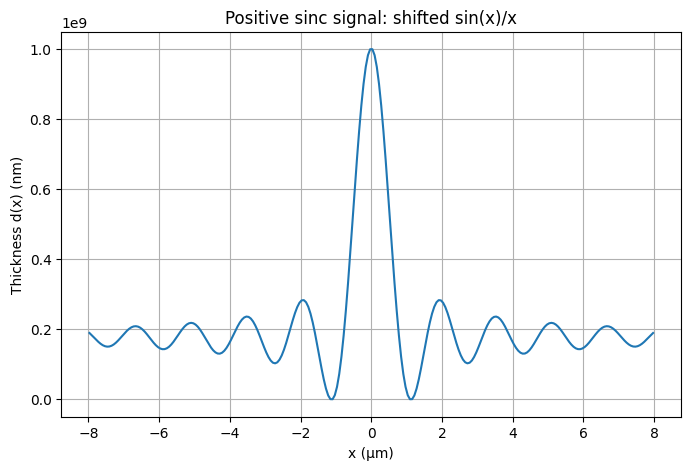

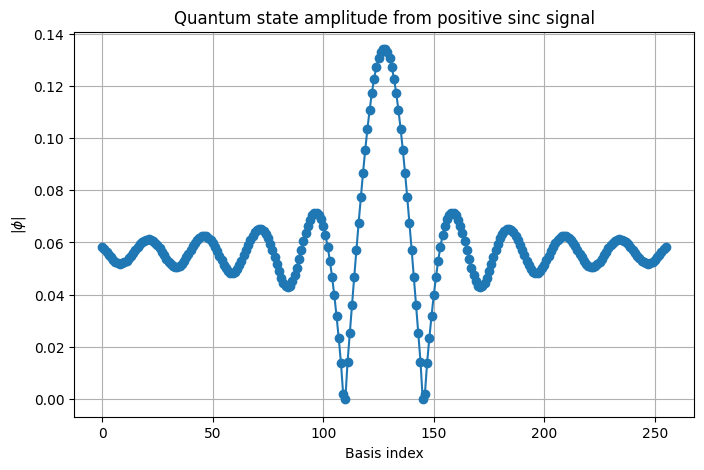

In [3]:
n_qubits = 8
Nx = 2**n_qubits

x = spatial_grid(T, Nx)

d = thickness_profile_positive_sinc(
    x=x,
    h=h,
    scale=sinc_scale,
    x0=0.0
)

f = phase_signal(d, n_refr, lam)

phi, alpha = phi_from_f(f)

phi = np.asarray(phi, dtype=complex)
phi = phi / np.linalg.norm(phi)

print("Symmetric d:", np.allclose(d, d[::-1]))
print("Symmetric phi:", np.allclose(phi, phi[::-1]))
print("alpha =", alpha)


plt.figure(figsize=(8, 5))
plt.plot(x * 1e6, d * 1e9)
plt.xlabel("x (µm)")
plt.ylabel("Thickness d(x) (nm)")
plt.title("Positive sinc signal: shifted sin(x)/x")
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(np.arange(Nx), np.abs(phi), "o-")
plt.xlabel("Basis index")
plt.ylabel(r"$|\phi|$")
plt.title("Quantum state amplitude from positive sinc signal")
plt.grid(True)
plt.show()

n_qubits: 8
norm phi: 0.9999999999999999

Original phi MPS bond dimensions
Bond profile: [2, 3, 4, 3, 2, 2, 1]
Max bond dimension: 4

number_of_layers: 1
Max bond dimension of chi: 6
Fidelity chi with |000...0>: 0.9518286667165446

number_of_layers: 2
Max bond dimension of chi: 5
Fidelity chi with |000...0>: 0.965033815995978

number_of_layers: 3
Max bond dimension of chi: 5
Fidelity chi with |000...0>: 0.9777775516454176

number_of_layers: 4
Max bond dimension of chi: 4
Fidelity chi with |000...0>: 0.961235832400525

number_of_layers: 5
Max bond dimension of chi: 5
Fidelity chi with |000...0>: 0.9217262454636682

number_of_layers: 6
Max bond dimension of chi: 6
Fidelity chi with |000...0>: 0.9447894900415057

number_of_layers: 7
Max bond dimension of chi: 7
Fidelity chi with |000...0>: 0.9115651600430946

number_of_layers: 8
Max bond dimension of chi: 8
Fidelity chi with |000...0>: 0.9262526819838391

number_of_layers: 9
Max bond dimension of chi: 8
Fidelity chi with |000...0>: 0.9326

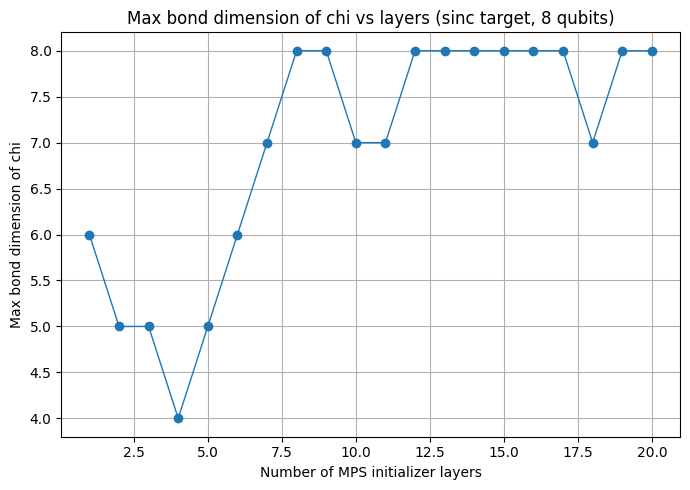

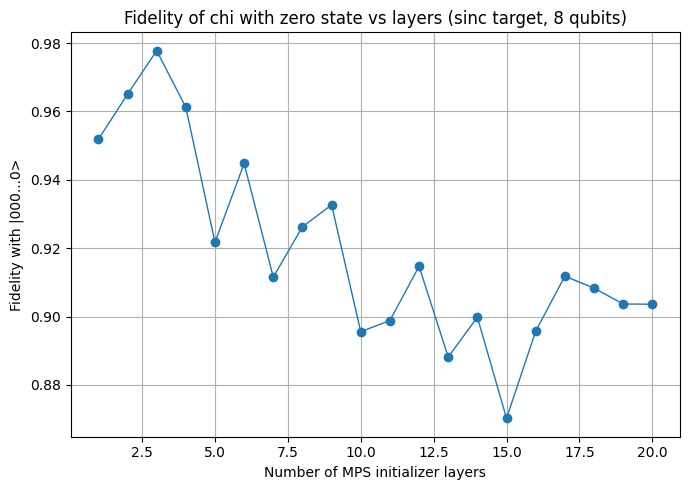

In [4]:
# ==================================================
# Imports (run once if not already imported)
# ==================================================
import numpy as np
import matplotlib.pyplot as plt
import quimb.tensor as qtn
from qiskit.quantum_info import Statevector
from qiskit_mps_initializer.datatypes import QuantumState


# ==================================================
# Settings
# ==================================================
layer_list = range(1, 21)      # start modest, extend later if still improving
quimb_cutoff = 1e-3


# ==================================================
# Target state and zero state (using your sinc-based phi)
# ==================================================
n_qubits = int(np.log2(len(phi)))

target_state = Statevector(phi)

zero_state = np.zeros_like(phi, dtype=complex)
zero_state[0] = 1.0

print("n_qubits:", n_qubits)
print("norm phi:", np.linalg.norm(phi))


# ==================================================
# Original phi bond dimension (before any circuit)
# ==================================================
qmps_phi = dense_state_to_quimb_mps(psi=phi, n_qubits=n_qubits, cutoff=quimb_cutoff)
phi_bond_profile, phi_max_bond = quimb_bond_report(qmps_phi)

print("\nOriginal phi MPS bond dimensions")
print("Bond profile:", phi_bond_profile)
print("Max bond dimension:", phi_max_bond)


# ==================================================
# Main loop: fresh circuit U(L) for each L
# ==================================================
layers = []
max_bond_chi_results = []
fidelity_zero_results = []

for number_of_layers in layer_list:

    print("\n" + "=" * 60)
    print("number_of_layers:", number_of_layers)
    print("=" * 60)

    phi_state = QuantumState.from_dense_data(data=phi, normalize=True)

    U_phi = phi_state.generate_mps_initializer_circuit(
        number_of_layers=number_of_layers,
    )

    U_phi_dagger = U_phi.inverse()

    chi_state = target_state.evolve(U_phi_dagger)

    chi = np.asarray(chi_state.data, dtype=complex)
    chi = chi / np.linalg.norm(chi)

    qmps_chi = dense_state_to_quimb_mps(psi=chi, n_qubits=n_qubits, cutoff=quimb_cutoff)
    bond_profile_chi, max_bond_chi = quimb_bond_report(qmps_chi)

    fidelity_zero = float(np.real(np.abs(np.vdot(zero_state, chi)) ** 2))

    layers.append(number_of_layers)
    max_bond_chi_results.append(max_bond_chi)
    fidelity_zero_results.append(fidelity_zero)

    print("Max bond dimension of chi:", max_bond_chi)
    print("Fidelity chi with |000...0>:", fidelity_zero)


layers = np.array(layers)
max_bond_chi_results = np.array(max_bond_chi_results)
fidelity_zero_results = np.array(fidelity_zero_results)


# ==================================================
# Plot 1: layers vs max bond dimension of chi
# ==================================================
plt.figure(figsize=(7, 5))
plt.plot(layers, max_bond_chi_results, marker="o", linewidth=1)
plt.xlabel("Number of MPS initializer layers")
plt.ylabel("Max bond dimension of chi")
plt.title(f"Max bond dimension of chi vs layers (sinc target, {n_qubits} qubits)")
plt.grid(True)
plt.tight_layout()
plt.show()


# ==================================================
# Plot 2: layers vs fidelity with |000...0>
# ==================================================
plt.figure(figsize=(7, 5))
plt.plot(layers, fidelity_zero_results, marker="o", linewidth=1)
plt.xlabel("Number of MPS initializer layers")
plt.ylabel("Fidelity with |000...0>")
plt.title(f"Fidelity of chi with zero state vs layers (sinc target, {n_qubits} qubits)")
plt.grid(True)
plt.tight_layout()
plt.show()